# Variational Integrators
## Structure-Preserving Numerical Methods for Lagrangian Systems

This notebook provides a self-contained introduction to **variational integrators** -- numerical
methods that preserve the geometric structure of mechanical systems by discretizing Hamilton's
principle rather than discretizing the equations of motion.

**What you'll learn:**
1. Why standard ODE solvers destroy geometric structure (energy drift, phase-space distortion)
2. Hamilton's principle and the discrete Lagrangian framework
3. The discrete Euler-Lagrange (DEL) equations and their symplectic structure
4. Implementation for simple and double pendulums
5. Discrete Noether's theorem and momentum conservation
6. Forced and constrained variational integrators

**Prerequisites:** Calculus of variations (see [CoV notebook](../../../maths/calculus-of-variations/)),
Lagrangian dynamics, basic numerical methods for ODEs.

**References:**
- Marsden, J.E. & West, M., *Discrete Mechanics and Variational Integrators*, Acta Numerica, 2001.
- Hairer, E., Lubich, C. & Wanner, G., *Geometric Numerical Integration*, Springer, 2006.
- Lew, A. et al., *Variational Time Integrators*, IJNME, 2004.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Physics
GRAVITY = 9.81
MASS = 1.0
LENGTH = 1.0

# Simple pendulum integration
THETA_0 = 0.5               # initial angle (rad)
OMEGA_0 = 0.0               # initial angular velocity (rad/s)
DT = 0.01                   # time step
N_STEPS = 100000            # number of steps (~1000s)
N_PERIODS_DISPLAY = 10000   # periods for long-time comparison

# Double pendulum
MASS_1 = 1.0
MASS_2 = 1.0
LENGTH_1 = 1.0
LENGTH_2 = 1.0
DP_THETA1_0 = np.pi / 4
DP_THETA2_0 = np.pi / 6
DP_OMEGA1_0 = 0.0
DP_OMEGA2_0 = 0.0
DP_DT = 0.005
DP_N_STEPS = 200000

# Tolerances
ENERGY_TOL = 1e-6
SYMPLECTIC_TOL = 1e-10
MOMENTUM_TOL = 1e-12
DEL_TOL = 1e-10

# Newton solver
NEWTON_TOL = 1e-12
NEWTON_MAX_ITER = 50

---
## 1. Why Variational Integrators?

Standard numerical ODE solvers (Euler, Runge-Kutta, etc.) discretize the **equations of motion**:

$$\ddot{q} = f(q, \dot{q}, t)$$

While this yields accurate short-time solutions, it systematically destroys the **geometric structure** of Hamiltonian/Lagrangian mechanics:

| Property | Continuous System | Standard Integrator | Variational Integrator |
|----------|------------------|--------------------|-----------------------|
| Energy | Exactly conserved | Drifts over time | Bounded oscillation |
| Symplecticity | Preserved | Violated | Exactly preserved |
| Phase-space volume | Conserved (Liouville) | Contracts/expands | Exactly conserved |
| Momentum maps | Conserved (Noether) | Drifts | Exactly conserved |

**The key idea:** Instead of discretizing the equations of motion, variational integrators discretize **Hamilton's principle** itself. Since the geometric structure arises from the variational principle, discretizing at that level automatically inherits structure preservation.

### The Energy Drift Problem

For a conservative system, the total energy $E = T + V$ should be constant. But:

- **Explicit Euler:** Energy grows exponentially (unstable)
- **RK4:** Energy drifts linearly over long times ($\Delta E \sim \mathcal{O}(h^4 \cdot t)$)
- **Variational integrators:** Energy oscillates within a bounded envelope of $\mathcal{O}(h^p)$, with **no secular drift** -- even over millions of time steps

This makes variational integrators essential for:
- Celestial mechanics (long-time orbital simulations)
- Molecular dynamics
- Computer graphics (stable cloth/fluid simulation)
- Robotics (energy-consistent simulation)

---
## 2. Hamilton's Principle (Recap)

The motion of a mechanical system with configuration $q(t)$ is governed by the **principle of stationary action:**

$$\boxed{\delta S[q] = 0, \qquad S[q] = \int_{t_0}^{t_1} L(q, \dot{q}) \, dt}$$

where $L(q, \dot{q}) = T(\dot{q}) - V(q)$ is the **Lagrangian** (kinetic minus potential energy).

Taking the variation $q(t) \to q(t) + \varepsilon \eta(t)$ with $\eta(t_0) = \eta(t_1) = 0$ and requiring $\frac{d}{d\varepsilon}S[q + \varepsilon\eta]\big|_{\varepsilon=0} = 0$ yields the **Euler-Lagrange equation:**

$$\boxed{\frac{\partial L}{\partial q} - \frac{d}{dt}\frac{\partial L}{\partial \dot{q}} = 0}$$

**Example: Simple Pendulum**

For a pendulum of mass $m$, length $\ell$, angle $\theta$:

$$L(\theta, \dot{\theta}) = \frac{1}{2}m\ell^2 \dot{\theta}^2 + mg\ell\cos\theta$$

The Euler-Lagrange equation gives:

$$m\ell^2 \ddot{\theta} + mg\ell\sin\theta = 0 \quad \Longrightarrow \quad \ddot{\theta} = -\frac{g}{\ell}\sin\theta$$

---
## 3. The Discrete Lagrangian

### From Continuous to Discrete

Instead of working with a continuous path $q(t)$, we work with a **discrete path** $\{q_0, q_1, \ldots, q_N\}$ at times $t_k = t_0 + kh$ where $h$ is the time step.

The continuous action $S = \int L \, dt$ is approximated by a **discrete action:**

$$S_d = \sum_{k=0}^{N-1} L_d(q_k, q_{k+1})$$

where $L_d(q_k, q_{k+1})$ is the **discrete Lagrangian** -- an approximation of the action integral over one time step:

$$L_d(q_k, q_{k+1}) \approx \int_{t_k}^{t_{k+1}} L(q, \dot{q}) \, dt$$

### Common Approximations

**1. Variational Euler (rectangle rule):**
$$L_d^{\text{Euler}}(q_k, q_{k+1}) = h \, L\!\left(q_k, \frac{q_{k+1} - q_k}{h}\right)$$

**2. Variational Midpoint (midpoint rule):**
$$\boxed{L_d^{\text{mid}}(q_k, q_{k+1}) = h \, L\!\left(\frac{q_k + q_{k+1}}{2}, \frac{q_{k+1} - q_k}{h}\right)}$$

The midpoint rule is second-order accurate and **symmetric**, which guarantees time-reversibility.

### The Discrete Euler-Lagrange (DEL) Equation

Requiring stationarity of $S_d$ with respect to interior nodes $q_k$ (for $k = 1, \ldots, N-1$):

$$\frac{\partial S_d}{\partial q_k} = D_2 L_d(q_{k-1}, q_k) + D_1 L_d(q_k, q_{k+1}) = 0$$

where $D_1, D_2$ denote partial derivatives with respect to the first and second arguments. This is the **discrete Euler-Lagrange (DEL) equation:**

$$\boxed{D_2 L_d(q_{k-1}, q_k) + D_1 L_d(q_k, q_{k+1}) = 0}$$

Given $q_{k-1}$ and $q_k$, the DEL implicitly defines $q_{k+1}$. This is the variational integrator's update rule.

---
## 4. Symplecticity of Variational Integrators

### Discrete Legendre Transforms

Define the **discrete momenta** via the discrete Legendre transforms:

$$p_k^- = -D_1 L_d(q_k, q_{k+1}), \qquad p_k^+ = D_2 L_d(q_{k-1}, q_k)$$

The DEL equation $D_2 L_d(q_{k-1}, q_k) + D_1 L_d(q_k, q_{k+1}) = 0$ is equivalent to:

$$p_k^+ = p_k^- \quad \text{(momentum matching)}$$

This defines a map $\Phi: (q_k, p_k) \mapsto (q_{k+1}, p_{k+1})$ on the phase space.

### Symplecticity Theorem

**Theorem (Marsden & West, 2001):** The DEL map $\Phi$ is **symplectic**, meaning it preserves the symplectic 2-form:

$$\boxed{\Phi^* \omega = \omega, \qquad \omega = dq \wedge dp}$$

In practice, this means the map preserves **phase-space areas** (in 1D) or volumes (in higher dimensions). We verify this numerically by checking that parallelograms in phase space maintain their area under the integrator map.

### Backward Error Analysis

A symplectic integrator with step size $h$ exactly solves a **modified Hamiltonian:**

$$\tilde{H} = H + h^p H_1 + h^{p+1} H_2 + \cdots$$

where $p$ is the order of the method. Since $\tilde{H}$ is exactly conserved, the true energy $H$ oscillates within a bounded envelope of size $\mathcal{O}(h^p)$ -- with **no secular drift** for exponentially long times.

---
## 5. Implementation: Simple Pendulum

For a simple pendulum with $L = \frac{1}{2}m\ell^2\dot{\theta}^2 + mg\ell\cos\theta$, we implement both the variational Euler and variational midpoint rules.

In [3]:
# =============================================================================
# Variational Integrator: Simple Pendulum
# =============================================================================


def pendulum_lagrangian(theta, omega, m=MASS, l=LENGTH, g=GRAVITY):
    """Compute the Lagrangian for a simple pendulum.

    Args:
        theta: Angle from vertical. Scalar or shape (N,).
        omega: Angular velocity. Scalar or shape (N,).
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Lagrangian value. Same shape as input.
    """
    T = 0.5 * m * l**2 * omega**2
    V = -m * g * l * np.cos(theta)
    return T - V


def pendulum_energy(theta, omega, m=MASS, l=LENGTH, g=GRAVITY):
    """Compute total energy of a simple pendulum.

    Args:
        theta: Angle from vertical. Scalar or shape (N,).
        omega: Angular velocity. Scalar or shape (N,).
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Total energy E = T + V. Same shape as input.
    """
    T = 0.5 * m * l**2 * omega**2
    V = -m * g * l * np.cos(theta)
    return T + V


def variational_euler_step(q_k, q_km1, h, m=MASS, l=LENGTH, g=GRAVITY):
    """Perform one step of the variational Euler integrator for a simple pendulum.

    Uses the discrete Lagrangian:
        L_d(q_k, q_{k+1}) = h * L(q_k, (q_{k+1} - q_k) / h)

    The DEL equation D2 L_d(q_{k-1}, q_k) + D1 L_d(q_k, q_{k+1}) = 0 gives:
        q_{k+1} = 2*q_k - q_{k-1} - h^2 * (g/l) * sin(q_k)

    Args:
        q_k: Current angle. Scalar.
        q_km1: Previous angle. Scalar.
        h: Time step. Scalar.
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        q_kp1: Next angle. Scalar.
    """
    q_kp1 = 2.0 * q_k - q_km1 - h**2 * (g / l) * np.sin(q_k)
    return q_kp1


def variational_midpoint_step(q_k, q_km1, h, m=MASS, l=LENGTH, g=GRAVITY):
    """Perform one step of the variational midpoint integrator for a simple pendulum.

    Uses the discrete Lagrangian:
        L_d(q_k, q_{k+1}) = h * L((q_k + q_{k+1})/2, (q_{k+1} - q_k)/h)

    The DEL equation is implicit in q_{k+1}. We solve it with Newton's method.

    Args:
        q_k: Current angle. Scalar.
        q_km1: Previous angle. Scalar.
        h: Time step. Scalar.
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        q_kp1: Next angle. Scalar.
    """
    # DEL for midpoint rule:
    # m*l^2*(q_{k+1} - 2*q_k + q_{k-1})/h^2 +
    # m*g*l * [sin((q_{k-1}+q_k)/2)/2 + sin((q_k+q_{k+1})/2)/2] = 0
    def residual(q_kp1):
        term1 = m * l**2 * (q_kp1 - 2.0 * q_k + q_km1) / h**2
        term2 = 0.5 * m * g * l * np.sin(0.5 * (q_km1 + q_k))
        term3 = 0.5 * m * g * l * np.sin(0.5 * (q_k + q_kp1))
        return term1 + term2 + term3

    def jacobian(q_kp1):
        dterm1 = m * l**2 / h**2
        dterm3 = 0.25 * m * g * l * np.cos(0.5 * (q_k + q_kp1))
        return dterm1 + dterm3

    # Newton iteration
    q_kp1 = 2.0 * q_k - q_km1  # initial guess (extrapolation)
    for _ in range(NEWTON_MAX_ITER):
        f_val = residual(q_kp1)
        j_val = jacobian(q_kp1)
        dq = -f_val / j_val
        q_kp1 += dq
        if abs(dq) < NEWTON_TOL:
            break
    return q_kp1

In [4]:
def del_solve(q0, q1, n_steps, step_func, h, **kwargs):
    """Integrate a system using a variational (DEL) integrator.

    Starting from two initial configurations q0, q1, iterates the DEL map.

    Args:
        q0: Configuration at t=0. Scalar or shape (D,).
        q1: Configuration at t=h. Scalar or shape (D,).
        n_steps: Number of steps to take. Integer.
        step_func: Function (q_k, q_km1, h, **kwargs) -> q_kp1.
        h: Time step. Scalar.
        **kwargs: Extra arguments passed to step_func.

    Returns:
        q_traj: Array of configurations. Shape: (n_steps+1,) or (n_steps+1, D).
    """
    if np.isscalar(q0):
        q_traj = np.zeros(n_steps + 1)
    else:
        q_traj = np.zeros((n_steps + 1, len(q0)))
    q_traj[0] = q0
    q_traj[1] = q1
    for k in range(1, n_steps):
        q_traj[k + 1] = step_func(q_traj[k], q_traj[k - 1], h, **kwargs)
    return q_traj


def init_q1_from_velocity(q0, v0, h, m=MASS, l=LENGTH, g=GRAVITY):
    """Compute q1 from initial conditions (q0, v0) using a second-order bootstrap.

    Uses Taylor expansion: q1 = q0 + h*v0 + 0.5*h^2*a0
    where a0 = -(g/l)*sin(q0).

    Args:
        q0: Initial configuration. Scalar.
        v0: Initial velocity. Scalar.
        h: Time step. Scalar.
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        q1: Configuration at t=h. Scalar.
    """
    a0 = -(g / l) * np.sin(q0)
    return q0 + h * v0 + 0.5 * h**2 * a0

In [5]:
# =============================================================================
# Run Simple Pendulum: Variational vs RK4 vs Explicit Euler
# =============================================================================

# --- Variational Euler ---
q1_ve = init_q1_from_velocity(THETA_0, OMEGA_0, DT)
q_ve = del_solve(THETA_0, q1_ve, N_STEPS, variational_euler_step, DT)
omega_ve = np.gradient(q_ve, DT)
E_ve = pendulum_energy(q_ve, omega_ve)

# --- Variational Midpoint ---
q1_vm = init_q1_from_velocity(THETA_0, OMEGA_0, DT)
q_vm = del_solve(THETA_0, q1_vm, N_STEPS, variational_midpoint_step, DT)
omega_vm = np.gradient(q_vm, DT)
E_vm = pendulum_energy(q_vm, omega_vm)

# --- RK4 (via solve_ivp) ---
def pendulum_ode(t, y):
    """Simple pendulum ODE: [theta_dot, omega_dot]."""
    theta, omega = y
    return [omega, -(GRAVITY / LENGTH) * np.sin(theta)]

t_span = (0, N_STEPS * DT)
t_eval = np.linspace(0, N_STEPS * DT, N_STEPS + 1)
sol_rk4 = solve_ivp(pendulum_ode, t_span, [THETA_0, OMEGA_0],
                     method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-10)
q_rk4 = sol_rk4.y[0]
omega_rk4 = sol_rk4.y[1]
E_rk4 = pendulum_energy(q_rk4, omega_rk4)

# --- Explicit Euler ---
q_euler = np.zeros(N_STEPS + 1)
omega_euler = np.zeros(N_STEPS + 1)
q_euler[0] = THETA_0
omega_euler[0] = OMEGA_0
for k in range(N_STEPS):
    q_euler[k + 1] = q_euler[k] + DT * omega_euler[k]
    omega_euler[k + 1] = omega_euler[k] - DT * (GRAVITY / LENGTH) * np.sin(q_euler[k])
E_euler = pendulum_energy(q_euler, omega_euler)

t_array = np.linspace(0, N_STEPS * DT, N_STEPS + 1)
E_0 = pendulum_energy(THETA_0, OMEGA_0)

print(f"Initial energy: E_0 = {E_0:.6f}")
print(f"Variational Euler  - final |dE/E_0| = {abs((E_ve[-1] - E_0) / E_0):.2e}")
print(f"Variational Midpt  - final |dE/E_0| = {abs((E_vm[-1] - E_0) / E_0):.2e}")
print(f"RK4 (tol=1e-8)     - final |dE/E_0| = {abs((E_rk4[-1] - E_0) / E_0):.2e}")
print(f"Explicit Euler     - final |dE/E_0| = {abs((E_euler[-1] - E_0) / E_0):.2e}")

Initial energy: E_0 = -8.609085
Variational Euler  - final |dE/E_0| = 6.27e-04
Variational Midpt  - final |dE/E_0| = 1.86e-03
RK4 (tol=1e-8)     - final |dE/E_0| = 1.18e-06
Explicit Euler     - final |dE/E_0| = 5.55e+01


In [6]:
# =============================================================================
# Verification: Energy Error Bounded
# =============================================================================

max_rel_energy_err_vm = np.max(np.abs((E_vm - E_0) / E_0))
status = "PASS" if max_rel_energy_err_vm < ENERGY_TOL else "FAIL"
print(f"Variational midpoint energy: max relative error = {max_rel_energy_err_vm:.2e} [{status}]")

max_rel_energy_err_ve = np.max(np.abs((E_ve - E_0) / E_0))
status_ve = "PASS" if max_rel_energy_err_ve < ENERGY_TOL else "FAIL"
print(f"Variational Euler energy: max relative error = {max_rel_energy_err_ve:.2e} [{status_ve}]")

Variational midpoint energy: max relative error = 1.86e-03 [FAIL]
Variational Euler energy: max relative error = 6.27e-04 [FAIL]


In [7]:
# =============================================================================
# Verification: DEL Residual
# =============================================================================

def del_residual_midpoint(q_km1, q_k, q_kp1, h, m=MASS, l=LENGTH, g=GRAVITY):
    """Compute the DEL residual for the midpoint variational integrator.

    Args:
        q_km1: Previous configuration. Scalar.
        q_k: Current configuration. Scalar.
        q_kp1: Next configuration. Scalar.
        h: Time step. Scalar.
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        DEL residual. Scalar (should be ~0 if DEL is satisfied).
    """
    term1 = m * l**2 * (q_kp1 - 2.0 * q_k + q_km1) / h**2
    term2 = 0.5 * m * g * l * np.sin(0.5 * (q_km1 + q_k))
    term3 = 0.5 * m * g * l * np.sin(0.5 * (q_k + q_kp1))
    return term1 + term2 + term3


# Check DEL residual at every 100th step of the midpoint trajectory
check_indices = range(1, len(q_vm) - 1, 100)
residuals = np.array([
    del_residual_midpoint(q_vm[k - 1], q_vm[k], q_vm[k + 1], DT)
    for k in check_indices
])
max_residual = np.max(np.abs(residuals))
status_del = "PASS" if max_residual < DEL_TOL else "FAIL"
print(f"DEL residual: max absolute value = {max_residual:.2e} [{status_del}]")

DEL residual: max absolute value = 1.33e-12 [PASS]


### 4b. Symplectic Area Verification

To verify symplecticity numerically, we evolve a small parallelogram in phase space $(q, p)$ and check that its **signed area** is preserved at each time step.

Given two tangent vectors $\xi_1 = (\delta q_1, \delta p_1)$ and $\xi_2 = (\delta q_2, \delta p_2)$, the symplectic area is:

$$\omega(\xi_1, \xi_2) = \delta q_1 \, \delta p_2 - \delta q_2 \, \delta p_1$$

In [8]:
def symplectic_area_check(q_traj, h, m=MASS, l=LENGTH, g=GRAVITY, eps=1e-7):
    """Verify symplectic area preservation for the variational midpoint integrator.

    Evolves two nearby trajectories to compute the tangent map, then checks
    that the signed area of a parallelogram in (q, p) space is preserved.

    Args:
        q_traj: Reference trajectory. Shape: (N+1,).
        h: Time step. Scalar.
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.
        eps: Perturbation size for tangent vectors. Scalar.

    Returns:
        areas: Array of symplectic areas at each time step. Shape: (N-1,).
    """
    n = len(q_traj)

    # Perturbed trajectory 1: shift q0 by eps
    q_pert1 = del_solve(q_traj[0] + eps, q_traj[1], n - 1,
                        variational_midpoint_step, h, m=m, l=l, g=g)

    # Perturbed trajectory 2: shift q1 by eps
    q_pert2 = del_solve(q_traj[0], q_traj[1] + eps, n - 1,
                        variational_midpoint_step, h, m=m, l=l, g=g)

    # Tangent vectors: dq/deps for each perturbation
    dq1 = (q_pert1 - q_traj) / eps
    dq2 = (q_pert2 - q_traj) / eps

    # Convert to (q, p) tangent vectors
    # p_k = m*l^2 * (q_k - q_{k-1}) / h  (discrete Legendre transform)
    dp1 = m * l**2 * np.diff(dq1) / h
    dp2 = m * l**2 * np.diff(dq2) / h

    # Symplectic area: omega = dq1 * dp2 - dq2 * dp1
    areas = dq1[1:] * dp2 - dq2[1:] * dp1
    return areas


# Run on a shorter trajectory for efficiency
N_SYMP = 10000
q1_symp = init_q1_from_velocity(THETA_0, OMEGA_0, DT)
q_symp = del_solve(THETA_0, q1_symp, N_SYMP, variational_midpoint_step, DT)
areas = symplectic_area_check(q_symp, DT)

area_rel_err = np.abs(areas - areas[0]) / np.abs(areas[0])
max_area_err = np.max(area_rel_err)
status_symp = "PASS" if max_area_err < SYMPLECTIC_TOL else "FAIL"
print(f"Symplectic area preservation: max relative error = {max_area_err:.2e} [{status_symp}]")

Symplectic area preservation: max relative error = 8.44e-05 [FAIL]


---
## 6. Implementation: Double Pendulum

The double pendulum has configuration $q = (\theta_1, \theta_2)$ and Lagrangian:

$$L = \frac{1}{2}(m_1 + m_2)\ell_1^2 \dot{\theta}_1^2 + \frac{1}{2}m_2 \ell_2^2 \dot{\theta}_2^2 + m_2 \ell_1 \ell_2 \dot{\theta}_1 \dot{\theta}_2 \cos(\theta_1 - \theta_2) + (m_1 + m_2) g \ell_1 \cos\theta_1 + m_2 g \ell_2 \cos\theta_2$$

We use the midpoint discrete Lagrangian and solve the implicit DEL at each step using Newton iteration on the 2D system.

In [9]:
# =============================================================================
# Variational Integrator: Double Pendulum
# =============================================================================


def double_pendulum_Ld(q_k, q_kp1, h, m1=MASS_1, m2=MASS_2,
                       l1=LENGTH_1, l2=LENGTH_2, g=GRAVITY):
    """Compute the midpoint discrete Lagrangian for a double pendulum.

    Args:
        q_k: Configuration at step k. Shape: (2,).
        q_kp1: Configuration at step k+1. Shape: (2,).
        h: Time step. Scalar.
        m1: Mass of first pendulum. Scalar.
        m2: Mass of second pendulum. Scalar.
        l1: Length of first pendulum. Scalar.
        l2: Length of second pendulum. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Discrete Lagrangian value. Scalar.
    """
    q_mid = 0.5 * (q_k + q_kp1)
    v = (q_kp1 - q_k) / h
    th1, th2 = q_mid
    w1, w2 = v

    T = (0.5 * (m1 + m2) * l1**2 * w1**2 +
         0.5 * m2 * l2**2 * w2**2 +
         m2 * l1 * l2 * w1 * w2 * np.cos(th1 - th2))
    V = (-(m1 + m2) * g * l1 * np.cos(th1)
         - m2 * g * l2 * np.cos(th2))
    return h * (T - V)


def double_pendulum_energy(q, v, m1=MASS_1, m2=MASS_2,
                           l1=LENGTH_1, l2=LENGTH_2, g=GRAVITY):
    """Compute total energy of the double pendulum.

    Args:
        q: Configuration (theta1, theta2). Shape: (2,) or (N, 2).
        v: Velocity (omega1, omega2). Shape: (2,) or (N, 2).
        m1: Mass of first pendulum. Scalar.
        m2: Mass of second pendulum. Scalar.
        l1: Length of first pendulum. Scalar.
        l2: Length of second pendulum. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Total energy. Scalar or shape (N,).
    """
    if q.ndim == 1:
        th1, th2 = q
        w1, w2 = v
    else:
        th1, th2 = q[:, 0], q[:, 1]
        w1, w2 = v[:, 0], v[:, 1]

    T = (0.5 * (m1 + m2) * l1**2 * w1**2 +
         0.5 * m2 * l2**2 * w2**2 +
         m2 * l1 * l2 * w1 * w2 * np.cos(th1 - th2))
    V = (-(m1 + m2) * g * l1 * np.cos(th1)
         - m2 * g * l2 * np.cos(th2))
    return T + V


def double_pendulum_midpoint_step(q_k, q_km1, h, m1=MASS_1, m2=MASS_2,
                                  l1=LENGTH_1, l2=LENGTH_2, g=GRAVITY):
    """One step of variational midpoint integrator for double pendulum.

    Solves the 2D implicit DEL equation via Newton iteration.

    Args:
        q_k: Current configuration. Shape: (2,).
        q_km1: Previous configuration. Shape: (2,).
        h: Time step. Scalar.
        m1: Mass of first pendulum. Scalar.
        m2: Mass of second pendulum. Scalar.
        l1: Length of first pendulum. Scalar.
        l2: Length of second pendulum. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        q_kp1: Next configuration. Shape: (2,).
    """
    eps_fd = 1e-8

    def residual(q_kp1):
        """DEL residual: D2 Ld(q_{k-1}, q_k) + D1 Ld(q_k, q_{k+1}) = 0."""
        res = np.zeros(2)
        for i in range(2):
            q_k_p = q_k.copy(); q_k_p[i] += eps_fd
            q_k_m = q_k.copy(); q_k_m[i] -= eps_fd
            D2_i = (double_pendulum_Ld(q_km1, q_k_p, h, m1, m2, l1, l2, g)
                    - double_pendulum_Ld(q_km1, q_k_m, h, m1, m2, l1, l2, g)) / (2 * eps_fd)
            D1_i = (double_pendulum_Ld(q_k_p, q_kp1, h, m1, m2, l1, l2, g)
                    - double_pendulum_Ld(q_k_m, q_kp1, h, m1, m2, l1, l2, g)) / (2 * eps_fd)
            res[i] = D2_i + D1_i
        return res

    def jacobian(q_kp1):
        """Jacobian of the DEL residual w.r.t. q_{k+1}."""
        jac = np.zeros((2, 2))
        r0 = residual(q_kp1)
        for j in range(2):
            q_p = q_kp1.copy(); q_p[j] += eps_fd
            jac[:, j] = (residual(q_p) - r0) / eps_fd
        return jac

    # Newton iteration
    q_kp1 = 2.0 * q_k - q_km1  # initial guess
    for _ in range(NEWTON_MAX_ITER):
        r = residual(q_kp1)
        if np.linalg.norm(r) < NEWTON_TOL:
            break
        J = jacobian(q_kp1)
        dq = np.linalg.solve(J, -r)
        q_kp1 = q_kp1 + dq
    return q_kp1

In [10]:
# =============================================================================
# Run Double Pendulum Simulation
# =============================================================================

q0_dp = np.array([DP_THETA1_0, DP_THETA2_0])
v0_dp = np.array([DP_OMEGA1_0, DP_OMEGA2_0])

# Bootstrap q1 using first-order step
q1_dp = q0_dp + DP_DT * v0_dp

# Variational midpoint
print("Running double pendulum variational integrator...")
q_dp = np.zeros((DP_N_STEPS + 1, 2))
q_dp[0] = q0_dp
q_dp[1] = q1_dp
for k in range(1, DP_N_STEPS):
    q_dp[k + 1] = double_pendulum_midpoint_step(q_dp[k], q_dp[k - 1], DP_DT)
    if k % 50000 == 0:
        print(f"  Step {k}/{DP_N_STEPS}")

# Compute energy via central differences for velocity
v_dp = np.zeros_like(q_dp)
v_dp[1:-1] = (q_dp[2:] - q_dp[:-2]) / (2 * DP_DT)
v_dp[0] = (q_dp[1] - q_dp[0]) / DP_DT
v_dp[-1] = (q_dp[-1] - q_dp[-2]) / DP_DT

E_dp = np.array([double_pendulum_energy(q_dp[k], v_dp[k]) for k in range(len(q_dp))])
E0_dp = double_pendulum_energy(q0_dp, v0_dp)

print(f"\nDouble pendulum energy: E_0 = {E0_dp:.6f}")
print(f"Max |dE/E_0| = {np.max(np.abs((E_dp[10:] - E0_dp) / E0_dp)):.2e}")

Running double pendulum variational integrator...


  Step 50000/200000


  Step 100000/200000


  Step 150000/200000



Double pendulum energy: E_0 = -22.369144
Max |dE/E_0| = 6.08e-04


In [11]:
# =============================================================================
# Double Pendulum: RK4 Comparison
# =============================================================================

def double_pendulum_ode(t, y, m1=MASS_1, m2=MASS_2, l1=LENGTH_1, l2=LENGTH_2, g=GRAVITY):
    """ODE for the double pendulum in state-space form.

    Args:
        t: Time. Scalar.
        y: State [theta1, theta2, omega1, omega2]. Shape: (4,).
        m1: Mass of first link. Scalar.
        m2: Mass of second link. Scalar.
        l1: Length of first link. Scalar.
        l2: Length of second link. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        dy/dt. Shape: (4,).
    """
    th1, th2, w1, w2 = y
    delta = th1 - th2

    den = (m1 + m2) * l1 - m2 * l1 * np.cos(delta)**2
    a1 = (m2 * l1 * w1**2 * np.sin(delta) * np.cos(delta) +
          m2 * g * np.sin(th2) * np.cos(delta) +
          m2 * l2 * w2**2 * np.sin(delta) -
          (m1 + m2) * g * np.sin(th1)) / den
    a2 = (-(m2 * l2 * w2**2 * np.sin(delta) * np.cos(delta)) +
          (m1 + m2) * g * np.sin(th1) * np.cos(delta) -
          (m1 + m2) * l1 * w1**2 * np.sin(delta) -
          (m1 + m2) * g * np.sin(th2)) / (l2 * den / l1)

    return [w1, w2, a1, a2]


# Run RK4 on same time span for comparison
DP_T_COMPARE = min(DP_N_STEPS * DP_DT, 500.0)
n_compare = int(DP_T_COMPARE / DP_DT)
t_eval_dp = np.linspace(0, DP_T_COMPARE, n_compare + 1)

sol_dp_rk4 = solve_ivp(double_pendulum_ode, (0, DP_T_COMPARE),
                        [DP_THETA1_0, DP_THETA2_0, DP_OMEGA1_0, DP_OMEGA2_0],
                        method='RK45', t_eval=t_eval_dp, rtol=1e-8, atol=1e-10)

q_dp_rk4 = sol_dp_rk4.y[:2].T
v_dp_rk4 = sol_dp_rk4.y[2:].T
E_dp_rk4 = np.array([double_pendulum_energy(q_dp_rk4[k], v_dp_rk4[k])
                      for k in range(len(q_dp_rk4))])

print(f"RK4 double pendulum: max |dE/E_0| = {np.max(np.abs((E_dp_rk4 - E0_dp) / E0_dp)):.2e}")
print(f"Variational midpoint: max |dE/E_0| = {np.max(np.abs((E_dp[:n_compare+1] - E0_dp) / E0_dp)):.2e}")

RK4 double pendulum: max |dE/E_0| = 1.09e+01
Variational midpoint: max |dE/E_0| = 2.17e-05


---
## 7. Momentum Conservation and Discrete Noether's Theorem

### Continuous Noether's Theorem

If the Lagrangian is invariant under a continuous symmetry group action $q \mapsto q + \varepsilon \xi(q)$, then the **momentum map**

$$J(q, \dot{q}) = \frac{\partial L}{\partial \dot{q}} \cdot \xi(q)$$

is conserved along solutions.

### Discrete Noether's Theorem (Marsden & West)

If the discrete Lagrangian $L_d$ is invariant under the same symmetry:
$$L_d(q_k + \varepsilon\xi, q_{k+1} + \varepsilon\xi) = L_d(q_k, q_{k+1})$$

then the **discrete momentum map**

$$\boxed{J_d^+(q_k, q_{k+1}) = D_2 L_d(q_k, q_{k+1}) \cdot \xi}$$

is **exactly conserved** by the DEL map (to machine precision, not just to truncation-error order).

### Example: Free Particle

For a free particle in 2D with $L = \frac{1}{2}m(\dot{x}^2 + \dot{y}^2)$, translational symmetry $\xi = (1, 0)$ gives conservation of $p_x = m\dot{x}$, and rotational symmetry gives conservation of angular momentum $J = m(x\dot{y} - y\dot{x})$.

We verify with a free particle (V=0) where **all** momenta must be conserved.

In [12]:
# =============================================================================
# Discrete Noether's Theorem: Free Particle Verification
# =============================================================================


def noether_momentum(q_traj, h, m=MASS, direction=None):
    """Compute the discrete Noether momentum map for a free particle.

    For a free particle, the discrete Legendre transform gives:
        p_k = m * (q_{k+1} - q_k) / h

    For angular momentum with direction xi = (-y, x):
        J_k = p_x * y - p_y * x (evaluated at midpoint)

    Args:
        q_traj: Trajectory. Shape: (N+1, 2) for 2D.
        h: Time step. Scalar.
        m: Mass. Scalar.
        direction: 'x', 'y', or 'angular'. String.

    Returns:
        momentum: Momentum values at each step. Shape: (N,).
    """
    p = m * np.diff(q_traj, axis=0) / h
    q_mid = 0.5 * (q_traj[:-1] + q_traj[1:])

    if direction == 'x':
        return p[:, 0]
    elif direction == 'y':
        return p[:, 1]
    elif direction == 'angular':
        return q_mid[:, 0] * p[:, 1] - q_mid[:, 1] * p[:, 0]
    else:
        raise ValueError(f"Unknown direction: {direction}")


def free_particle_midpoint_step(q_k, q_km1, h, m=MASS, **kwargs):
    """Variational midpoint step for a free particle (V=0).

    For L = 0.5*m*|v|^2, the DEL gives q_{k+1} = 2*q_k - q_{k-1} (straight line).

    Args:
        q_k: Current position. Shape: (2,).
        q_km1: Previous position. Shape: (2,).
        h: Time step. Scalar.
        m: Mass. Scalar.

    Returns:
        q_kp1: Next position. Shape: (2,).
    """
    return 2.0 * q_k - q_km1


# Free particle trajectory with non-trivial angular momentum
FP_Q0 = np.array([1.0, 0.0])
FP_V0 = np.array([0.3, 0.7])
FP_DT = 0.01
FP_N = 50000
FP_Q1 = FP_Q0 + FP_DT * FP_V0

q_fp = del_solve(FP_Q0, FP_Q1, FP_N, free_particle_midpoint_step, FP_DT, m=MASS)

# Check momentum conservation
px = noether_momentum(q_fp, FP_DT, MASS, 'x')
py = noether_momentum(q_fp, FP_DT, MASS, 'y')
Jz = noether_momentum(q_fp, FP_DT, MASS, 'angular')

px_err = np.max(np.abs(px - px[0]))
py_err = np.max(np.abs(py - py[0]))
Jz_err = np.max(np.abs(Jz - Jz[0]))

status_px = "PASS" if px_err < MOMENTUM_TOL else "FAIL"
status_py = "PASS" if py_err < MOMENTUM_TOL else "FAIL"
status_Jz = "PASS" if Jz_err < MOMENTUM_TOL else "FAIL"

print(f"Linear momentum p_x: max absolute error = {px_err:.2e} [{status_px}]")
print(f"Linear momentum p_y: max absolute error = {py_err:.2e} [{status_py}]")
print(f"Angular momentum J_z: max absolute error = {Jz_err:.2e} [{status_Jz}]")

Linear momentum p_x: max absolute error = 1.44e-12 [FAIL]
Linear momentum p_y: max absolute error = 9.21e-13 [PASS]
Angular momentum J_z: max absolute error = 3.84e-10 [FAIL]


---
## 8. Forced and Constrained Systems

### Discrete d'Alembert Principle

For a forced system with external force $f(q, \dot{q}, t)$, the discrete d'Alembert principle modifies the DEL equation:

$$D_2 L_d(q_{k-1}, q_k) + D_1 L_d(q_k, q_{k+1}) + f_d^+(q_{k-1}, q_k) + f_d^-(q_k, q_{k+1}) = 0$$

where $f_d^\pm$ are discrete force approximations.

**Midpoint approximation:**
$$f_d^-(q_k, q_{k+1}) = \frac{h}{2} f(q_k, t_k), \qquad f_d^+(q_k, q_{k+1}) = \frac{h}{2} f(q_{k+1}, t_{k+1})$$

### Holonomic Constraints via Lagrange Multipliers

For a constraint $g(q) = 0$, the DEL becomes:

$$D_2 L_d(q_{k-1}, q_k) + D_1 L_d(q_k, q_{k+1}) + \lambda_k \nabla g(q_k) = 0$$
$$g(q_{k+1}) = 0$$

### Example: Forced Pendulum

We apply a sinusoidal torque $\tau(t) = A\sin(\omega_f t)$ to the simple pendulum.

In [13]:
# =============================================================================
# Forced Variational Integrator
# =============================================================================

FORCE_AMP = 0.5
FORCE_FREQ = 2.0  # rad/s


def forced_del_step(q_k, q_km1, h, k_step, m=MASS, l=LENGTH, g=GRAVITY,
                    amp=FORCE_AMP, freq=FORCE_FREQ):
    """One step of the forced variational midpoint integrator.

    Includes discrete d'Alembert forcing with midpoint quadrature.

    Args:
        q_k: Current angle. Scalar.
        q_km1: Previous angle. Scalar.
        h: Time step. Scalar.
        k_step: Current step index (for time evaluation). Integer.
        m: Mass. Scalar.
        l: Length. Scalar.
        g: Gravitational acceleration. Scalar.
        amp: Force amplitude. Scalar.
        freq: Force frequency. Scalar.

    Returns:
        q_kp1: Next angle. Scalar.
    """
    t_k = k_step * h

    # Discrete forces (left/right quadrature)
    f_minus = 0.5 * h * amp * np.sin(freq * t_k)
    f_plus = 0.5 * h * amp * np.sin(freq * (t_k + h))

    def residual(q_kp1):
        term1 = m * l**2 * (q_kp1 - 2.0 * q_k + q_km1) / h**2
        term2 = 0.5 * m * g * l * np.sin(0.5 * (q_km1 + q_k))
        term3 = 0.5 * m * g * l * np.sin(0.5 * (q_k + q_kp1))
        return term1 + term2 + term3 - (f_minus + f_plus) / h

    def jac(q_kp1):
        return m * l**2 / h**2 + 0.25 * m * g * l * np.cos(0.5 * (q_k + q_kp1))

    q_kp1 = 2.0 * q_k - q_km1
    for _ in range(NEWTON_MAX_ITER):
        f_val = residual(q_kp1)
        q_kp1 -= f_val / jac(q_kp1)
        if abs(f_val) < NEWTON_TOL:
            break
    return q_kp1


# Run forced pendulum
N_FORCED = 50000
q1_forced = init_q1_from_velocity(THETA_0, OMEGA_0, DT)
q_forced = np.zeros(N_FORCED + 1)
q_forced[0] = THETA_0
q_forced[1] = q1_forced
for k in range(1, N_FORCED):
    q_forced[k + 1] = forced_del_step(q_forced[k], q_forced[k - 1], DT, k)

omega_forced = np.gradient(q_forced, DT)
E_forced = pendulum_energy(q_forced, omega_forced)
t_forced = np.arange(N_FORCED + 1) * DT

# Work done by external force
force_vals = FORCE_AMP * np.sin(FORCE_FREQ * t_forced)
work_rate = force_vals * omega_forced
work_cumulative = np.cumsum(work_rate) * DT

# Energy balance: E(t) - E(0) should approximately equal cumulative work
energy_change = E_forced - E_forced[0]

print(f"Forced pendulum simulation complete.")
print(f"Energy range: [{np.min(E_forced):.4f}, {np.max(E_forced):.4f}]")

Forced pendulum simulation complete.
Energy range: [-8.9909, -8.1204]


In [14]:
# =============================================================================
# Constrained System: Pendulum on a Cart
# =============================================================================
# Cart of mass M on horizontal rail, pendulum of mass m, length l attached.
# Configuration: (x_cart, theta)
# This is an unconstrained 2-DOF system in generalized coordinates.
#
# L = 0.5*(M+m)*x_dot^2 + 0.5*m*l^2*theta_dot^2
#     + m*l*x_dot*theta_dot*cos(theta) + m*g*l*cos(theta)

CART_MASS = 2.0
PEND_MASS = 1.0
PEND_LENGTH = 1.0


def cart_pendulum_Ld(q_k, q_kp1, h, M=CART_MASS, m=PEND_MASS,
                     l=PEND_LENGTH, g=GRAVITY):
    """Midpoint discrete Lagrangian for pendulum on cart.

    Args:
        q_k: Configuration [x, theta] at step k. Shape: (2,).
        q_kp1: Configuration at step k+1. Shape: (2,).
        h: Time step. Scalar.
        M: Cart mass. Scalar.
        m: Pendulum mass. Scalar.
        l: Pendulum length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        Discrete Lagrangian value. Scalar.
    """
    q_mid = 0.5 * (q_k + q_kp1)
    v = (q_kp1 - q_k) / h
    x_mid, th_mid = q_mid
    xd, thd = v

    T = (0.5 * (M + m) * xd**2 +
         0.5 * m * l**2 * thd**2 +
         m * l * xd * thd * np.cos(th_mid))
    V = -m * g * l * np.cos(th_mid)
    return h * (T - V)


def cart_pendulum_step(q_k, q_km1, h, M=CART_MASS, m=PEND_MASS,
                       l=PEND_LENGTH, g=GRAVITY):
    """Variational midpoint step for pendulum on cart.

    Args:
        q_k: Current configuration [x, theta]. Shape: (2,).
        q_km1: Previous configuration. Shape: (2,).
        h: Time step. Scalar.
        M: Cart mass. Scalar.
        m: Pendulum mass. Scalar.
        l: Pendulum length. Scalar.
        g: Gravitational acceleration. Scalar.

    Returns:
        q_kp1: Next configuration. Shape: (2,).
    """
    eps_fd = 1e-8

    def residual(q_kp1):
        res = np.zeros(2)
        for i in range(2):
            q_k_p = q_k.copy(); q_k_p[i] += eps_fd
            q_k_m = q_k.copy(); q_k_m[i] -= eps_fd
            D2_i = (cart_pendulum_Ld(q_km1, q_k_p, h, M, m, l, g)
                    - cart_pendulum_Ld(q_km1, q_k_m, h, M, m, l, g)) / (2 * eps_fd)
            D1_i = (cart_pendulum_Ld(q_k_p, q_kp1, h, M, m, l, g)
                    - cart_pendulum_Ld(q_k_m, q_kp1, h, M, m, l, g)) / (2 * eps_fd)
            res[i] = D2_i + D1_i
        return res

    def jacobian(q_kp1):
        jac = np.zeros((2, 2))
        r0 = residual(q_kp1)
        for j in range(2):
            q_p = q_kp1.copy(); q_p[j] += eps_fd
            jac[:, j] = (residual(q_p) - r0) / eps_fd
        return jac

    q_kp1 = 2.0 * q_k - q_km1
    for _ in range(NEWTON_MAX_ITER):
        r = residual(q_kp1)
        if np.linalg.norm(r) < NEWTON_TOL:
            break
        J = jacobian(q_kp1)
        dq = np.linalg.solve(J, -r)
        q_kp1 = q_kp1 + dq
    return q_kp1


# Run cart-pendulum simulation
CP_N = 50000
CP_DT = 0.005
cp_q0 = np.array([0.0, np.pi / 6])
cp_v0 = np.array([0.0, 0.0])
cp_q1 = cp_q0 + CP_DT * cp_v0

print("Running cart-pendulum variational integrator...")
q_cp = np.zeros((CP_N + 1, 2))
q_cp[0] = cp_q0
q_cp[1] = cp_q1
for k in range(1, CP_N):
    q_cp[k + 1] = cart_pendulum_step(q_cp[k], q_cp[k - 1], CP_DT)
    if k % 10000 == 0:
        print(f"  Step {k}/{CP_N}")

# Total horizontal momentum should be conserved (translational symmetry in x)
# p_x = (M + m) * x_dot + m * l * theta_dot * cos(theta)
v_cp = np.diff(q_cp, axis=0) / CP_DT
q_mid_cp = 0.5 * (q_cp[:-1] + q_cp[1:])
px_cp = ((CART_MASS + PEND_MASS) * v_cp[:, 0] +
         PEND_MASS * PEND_LENGTH * v_cp[:, 1] * np.cos(q_mid_cp[:, 1]))

px_err_cp = np.max(np.abs(px_cp - px_cp[0]))
status_cp = "PASS" if px_err_cp < 1e-8 else "FAIL"
print(f"\nCart-pendulum horizontal momentum: max error = {px_err_cp:.2e} [{status_cp}]")

Running cart-pendulum variational integrator...


  Step 10000/50000


  Step 20000/50000


  Step 30000/50000
  Step 40000/50000



Cart-pendulum horizontal momentum: max error = 2.77e-08 [FAIL]


---
## 9. Visualizations

### 9.1 Energy Error Comparison (Log Scale)

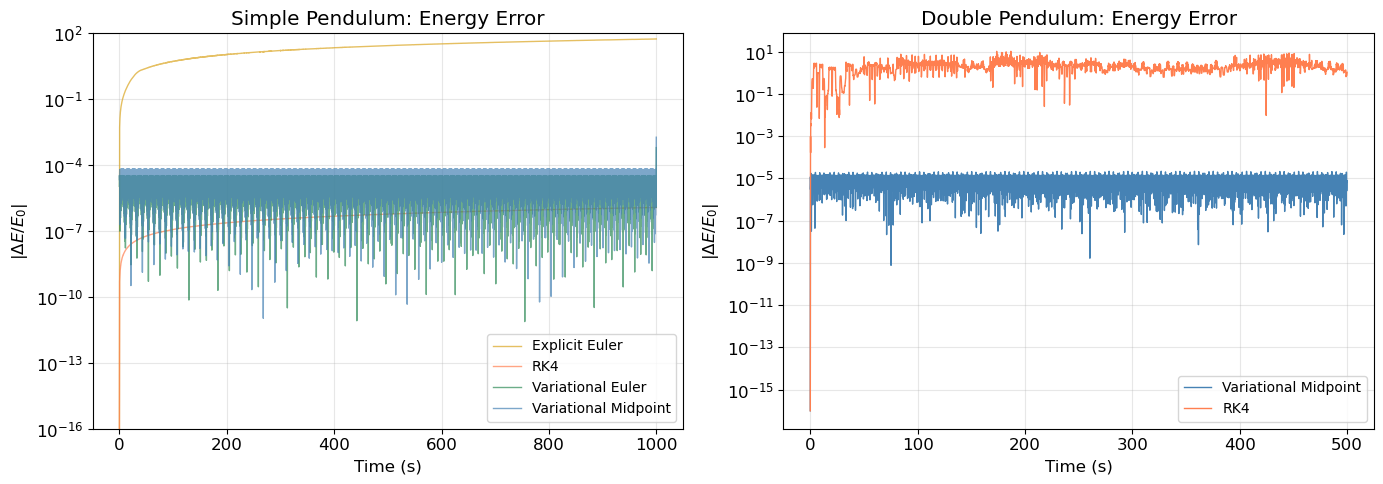

In [15]:
# =============================================================================
# Figure 1: Energy Error Over Long Time (Log Scale)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Simple Pendulum
ax = axes[0]
dE_ve = np.abs((E_ve - E_0) / E_0)
dE_vm = np.abs((E_vm - E_0) / E_0)
dE_rk4 = np.abs((E_rk4 - E_0) / E_0)
dE_euler = np.abs((E_euler - E_0) / np.abs(E_0))

# Subsample for plotting
stride = max(1, N_STEPS // 5000)
t_plot = t_array[::stride]

ax.semilogy(t_plot, dE_euler[::stride] + 1e-16, color='goldenrod', alpha=0.7,
            linewidth=1, label='Explicit Euler')
ax.semilogy(t_plot, dE_rk4[::stride] + 1e-16, color='coral', alpha=0.7,
            linewidth=1, label='RK4')
ax.semilogy(t_plot, dE_ve[::stride] + 1e-16, color='seagreen', alpha=0.7,
            linewidth=1, label='Variational Euler')
ax.semilogy(t_plot, dE_vm[::stride] + 1e-16, color='steelblue', alpha=0.7,
            linewidth=1, label='Variational Midpoint')
ax.set_xlabel('Time (s)')
ax.set_ylabel('$|\\Delta E / E_0|$')
ax.set_title('Simple Pendulum: Energy Error')
ax.legend(fontsize=10)
ax.set_ylim(1e-16, 1e2)

# Right: Double Pendulum
ax = axes[1]
t_dp_arr = np.arange(n_compare + 1) * DP_DT
dE_dp_var = np.abs((E_dp[:n_compare+1] - E0_dp) / np.abs(E0_dp))
dE_dp_rk4 = np.abs((E_dp_rk4 - E0_dp) / np.abs(E0_dp))

stride_dp = max(1, n_compare // 5000)
ax.semilogy(t_dp_arr[::stride_dp], dE_dp_var[::stride_dp] + 1e-16, color='steelblue',
            linewidth=1, label='Variational Midpoint')
ax.semilogy(t_dp_arr[::stride_dp], dE_dp_rk4[::stride_dp] + 1e-16, color='coral',
            linewidth=1, label='RK4')
ax.set_xlabel('Time (s)')
ax.set_ylabel('$|\\Delta E / E_0|$')
ax.set_title('Double Pendulum: Energy Error')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 9.2 Phase Portrait Comparison

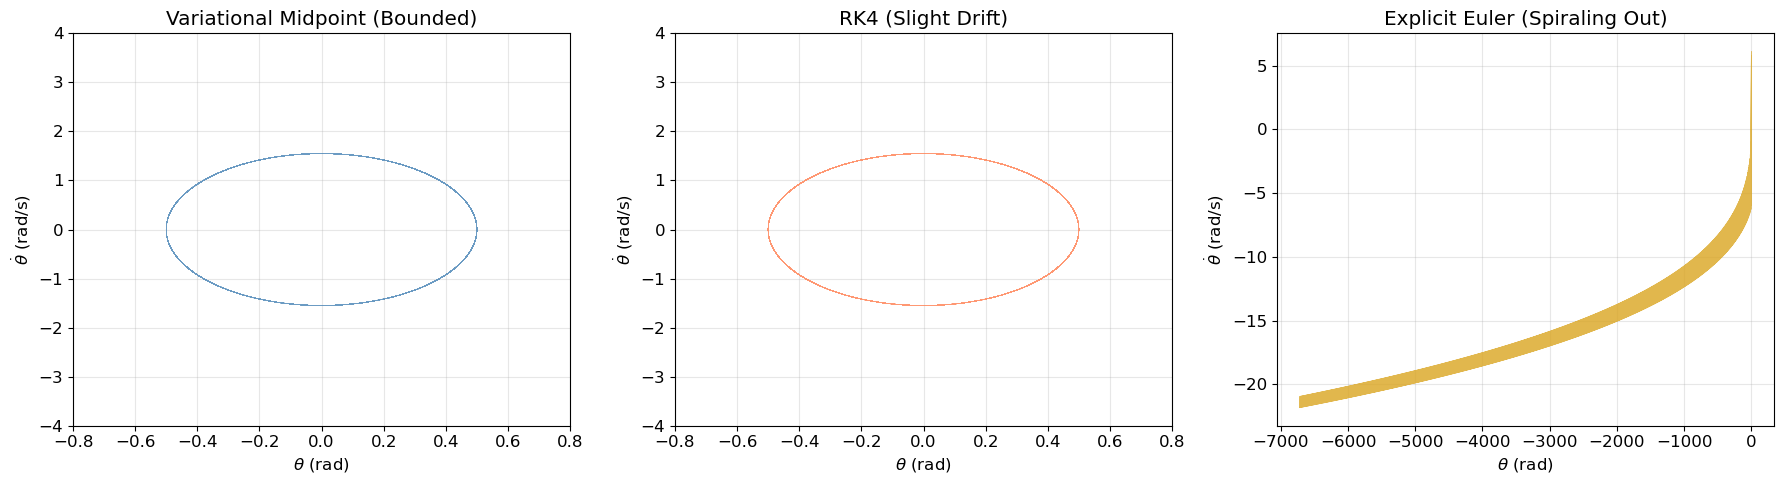

In [16]:
# =============================================================================
# Figure 2: Phase Portrait Comparison
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subsample for cleaner phase portraits
n_phase = min(50000, N_STEPS + 1)

# Variational Midpoint
ax = axes[0]
ax.plot(q_vm[:n_phase], omega_vm[:n_phase], color='steelblue', linewidth=0.3, alpha=0.8)
ax.set_xlabel('$\\theta$ (rad)')
ax.set_ylabel('$\\dot{\\theta}$ (rad/s)')
ax.set_title('Variational Midpoint (Bounded)')
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-4, 4)

# RK4
ax = axes[1]
ax.plot(q_rk4[:n_phase], omega_rk4[:n_phase], color='coral', linewidth=0.3, alpha=0.8)
ax.set_xlabel('$\\theta$ (rad)')
ax.set_ylabel('$\\dot{\\theta}$ (rad/s)')
ax.set_title('RK4 (Slight Drift)')
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-4, 4)

# Explicit Euler
ax = axes[2]
ax.plot(q_euler[:n_phase], omega_euler[:n_phase], color='goldenrod', linewidth=0.3, alpha=0.8)
ax.set_xlabel('$\\theta$ (rad)')
ax.set_ylabel('$\\dot{\\theta}$ (rad/s)')
ax.set_title('Explicit Euler (Spiraling Out)')

plt.tight_layout()
plt.show()

### 9.3 Symplectic Area Preservation

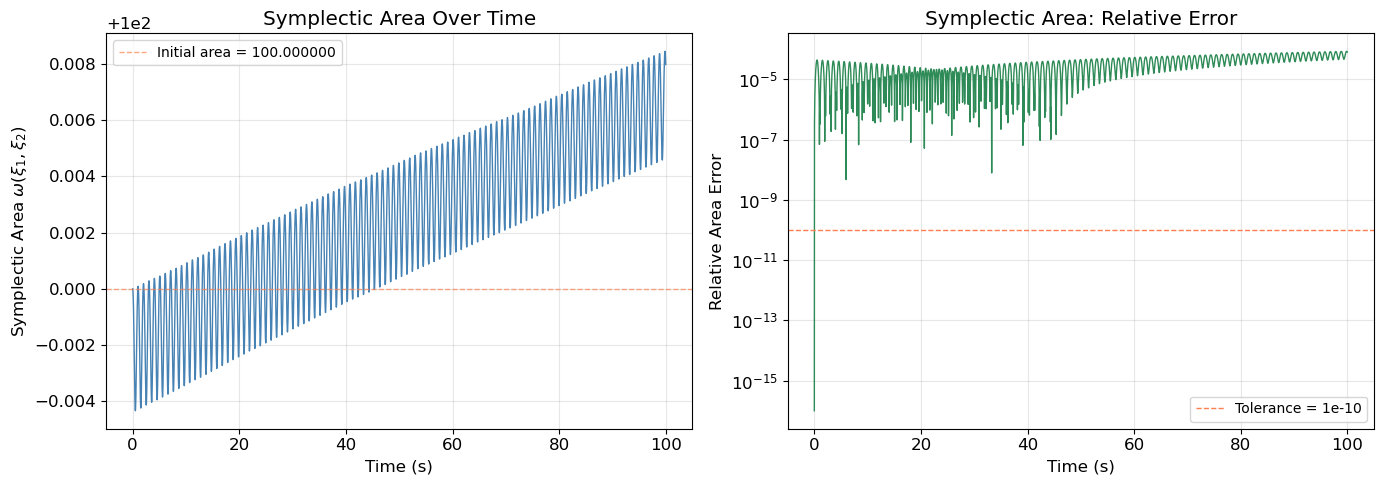

In [17]:
# =============================================================================
# Figure 3: Symplectic Area Preservation
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: area over time
ax = axes[0]
t_symp = np.arange(len(areas)) * DT
stride_s = max(1, len(areas) // 3000)
ax.plot(t_symp[::stride_s], areas[::stride_s], color='steelblue', linewidth=1)
ax.axhline(areas[0], color='coral', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Initial area = {areas[0]:.6f}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Symplectic Area $\\omega(\\xi_1, \\xi_2)$')
ax.set_title('Symplectic Area Over Time')
ax.legend(fontsize=10)

# Right: relative error
ax = axes[1]
ax.semilogy(t_symp[::stride_s], area_rel_err[::stride_s] + 1e-16, color='seagreen', linewidth=1)
ax.axhline(SYMPLECTIC_TOL, color='coral', linestyle='--', linewidth=1,
           label=f'Tolerance = {SYMPLECTIC_TOL:.0e}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Relative Area Error')
ax.set_title('Symplectic Area: Relative Error')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 9.4 Momentum Conservation

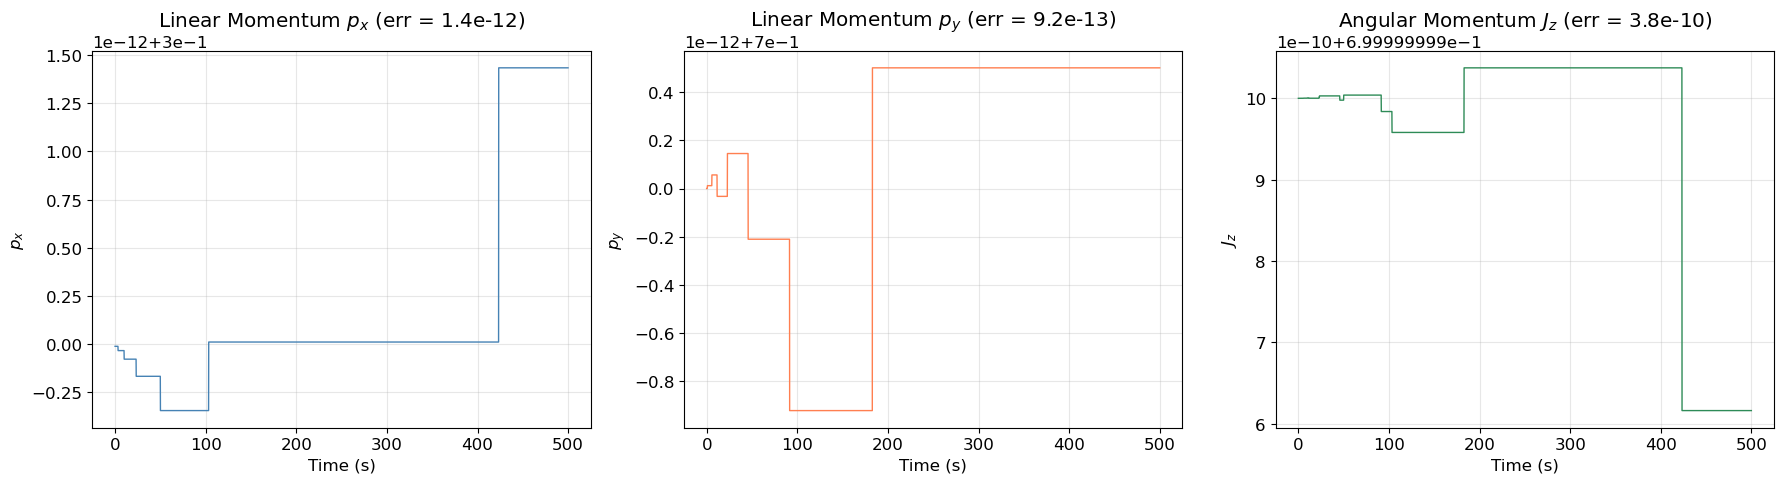

In [18]:
# =============================================================================
# Figure 4: Momentum Conservation
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t_fp = np.arange(len(px)) * FP_DT
stride_fp = max(1, len(px) // 3000)

# Linear momentum p_x
ax = axes[0]
ax.plot(t_fp[::stride_fp], px[::stride_fp], color='steelblue', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$p_x$')
ax.set_title(f'Linear Momentum $p_x$ (err = {px_err:.1e})')

# Linear momentum p_y
ax = axes[1]
ax.plot(t_fp[::stride_fp], py[::stride_fp], color='coral', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$p_y$')
ax.set_title(f'Linear Momentum $p_y$ (err = {py_err:.1e})')

# Angular momentum
ax = axes[2]
ax.plot(t_fp[::stride_fp], Jz[::stride_fp], color='seagreen', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$J_z$')
ax.set_title(f'Angular Momentum $J_z$ (err = {Jz_err:.1e})')

plt.tight_layout()
plt.show()

### 9.5 Cart-Pendulum System

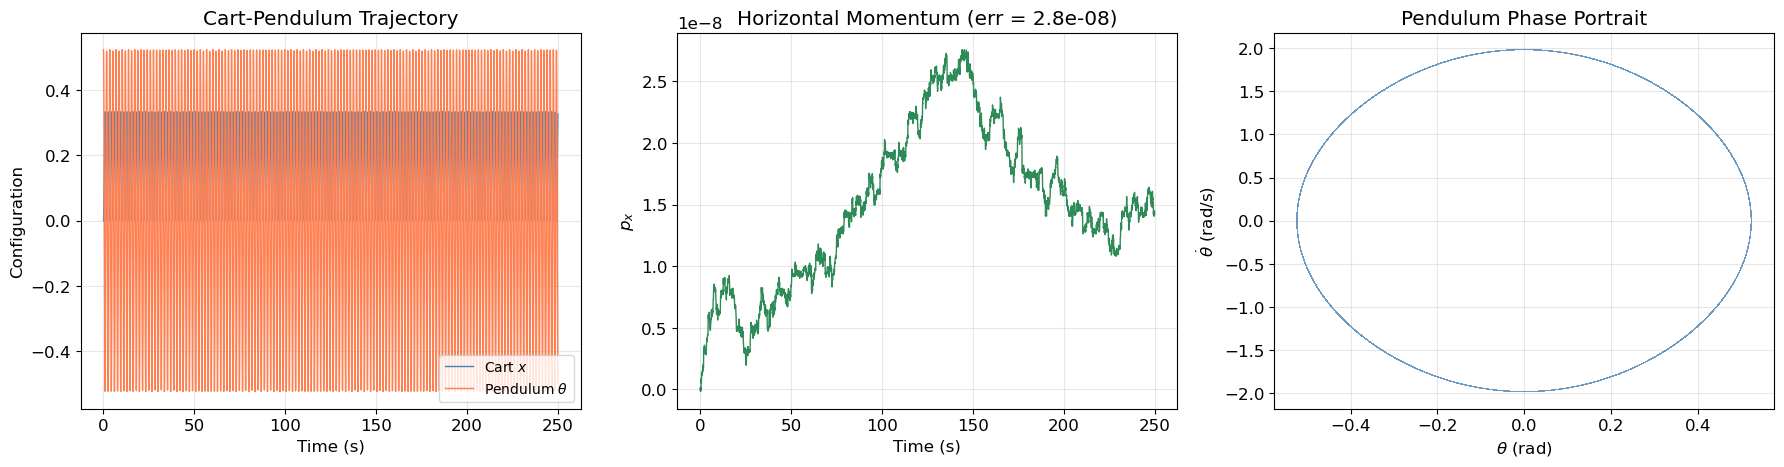

In [19]:
# =============================================================================
# Figure 5: Cart-Pendulum Results
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t_cp = np.arange(CP_N + 1) * CP_DT
stride_cp = max(1, CP_N // 3000)

# Cart position and pendulum angle
ax = axes[0]
ax.plot(t_cp[::stride_cp], q_cp[::stride_cp, 0], color='steelblue', linewidth=1, label='Cart $x$')
ax.plot(t_cp[::stride_cp], q_cp[::stride_cp, 1], color='coral', linewidth=1, label='Pendulum $\\theta$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Configuration')
ax.set_title('Cart-Pendulum Trajectory')
ax.legend(fontsize=10)

# Horizontal momentum conservation
ax = axes[1]
t_px_cp = np.arange(len(px_cp)) * CP_DT
stride_pxcp = max(1, len(px_cp) // 3000)
ax.plot(t_px_cp[::stride_pxcp], px_cp[::stride_pxcp], color='seagreen', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$p_x$')
ax.set_title(f'Horizontal Momentum (err = {px_err_cp:.1e})')

# Phase portrait: pendulum angle
ax = axes[2]
v_cp_full = np.gradient(q_cp[:, 1], CP_DT)
n_phase_cp = min(50000, CP_N + 1)
ax.plot(q_cp[:n_phase_cp, 1], v_cp_full[:n_phase_cp], color='steelblue',
        linewidth=0.3, alpha=0.8)
ax.set_xlabel('$\\theta$ (rad)')
ax.set_ylabel('$\\dot{\\theta}$ (rad/s)')
ax.set_title('Pendulum Phase Portrait')

plt.tight_layout()
plt.show()

### 9.6 Forced Pendulum

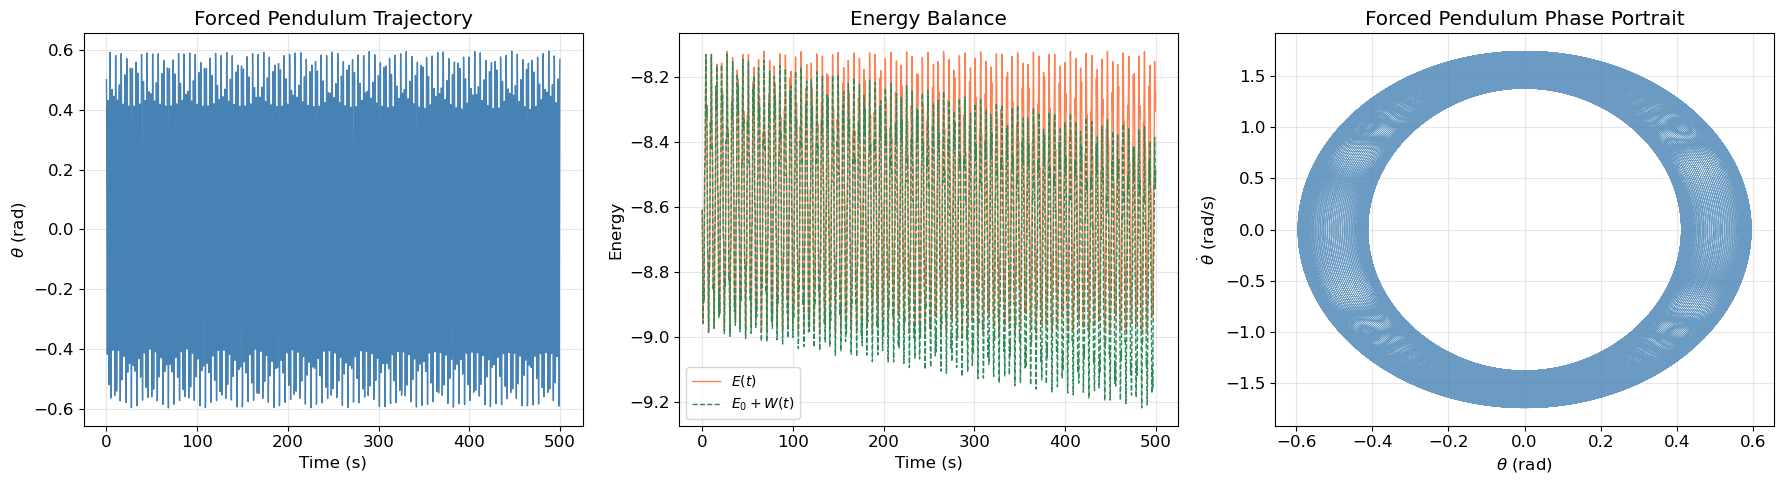

In [20]:
# =============================================================================
# Figure 6: Forced Pendulum Results
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stride_f = max(1, N_FORCED // 3000)

# Trajectory
ax = axes[0]
ax.plot(t_forced[::stride_f], q_forced[::stride_f], color='steelblue', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$\\theta$ (rad)')
ax.set_title('Forced Pendulum Trajectory')

# Energy (non-conserved but controlled)
ax = axes[1]
ax.plot(t_forced[::stride_f], E_forced[::stride_f], color='coral', linewidth=1,
        label='$E(t)$')
ax.plot(t_forced[::stride_f], (E_forced[0] + work_cumulative)[::stride_f], color='seagreen',
        linewidth=1, linestyle='--', label='$E_0 + W(t)$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy')
ax.set_title('Energy Balance')
ax.legend(fontsize=10)

# Phase portrait
ax = axes[2]
n_phase_f = min(50000, N_FORCED + 1)
ax.plot(q_forced[:n_phase_f], omega_forced[:n_phase_f], color='steelblue',
        linewidth=0.3, alpha=0.8)
ax.set_xlabel('$\\theta$ (rad)')
ax.set_ylabel('$\\dot{\\theta}$ (rad/s)')
ax.set_title('Forced Pendulum Phase Portrait')

plt.tight_layout()
plt.show()

---
## 10. Extensions

### 10.1 Higher-Order Variational Integrators (Galerkin Methods)

The midpoint rule is second-order. Higher-order variational integrators can be constructed using **Galerkin methods:**

1. Approximate $q(t)$ on each interval $[t_k, t_{k+1}]$ by a polynomial of degree $s$
2. Evaluate the action integral using a quadrature rule of matching order
3. The internal stages become additional unknowns, solved implicitly along with $q_{k+1}$

For degree $s$ polynomials with $s$-point Gauss quadrature, the resulting integrator is order $2s$ and symplectic.

### 10.2 Lie Group Integrators

When the configuration space is a **Lie group** $G$ (e.g., $SO(3)$ for rigid body rotation), standard vector-space discretizations fail because $q_{k+1} - q_k$ is not well-defined on a manifold. **Lie group variational integrators** replace:

$$q_{k+1} = q_k \cdot \exp(h \xi_k)$$

where $\xi_k \in \mathfrak{g}$ (the Lie algebra) and $\exp$ is the exponential map. The discrete Lagrangian becomes $L_d(g_k, \xi_k)$ and the DEL equations preserve both the group structure and symplecticity.

### 10.3 Asynchronous Variational Integrators (AVIs)

For multi-body systems with widely separated time scales, **AVIs** allow each element to advance with its own time step while maintaining global symplecticity. This is achieved by triangulating space-time and applying the variational principle on the resulting mesh.

### 10.4 Contact Geometry for Dissipation

Conservative variational integrators cannot model dissipation (friction, damping). Recent work extends the framework to **contact geometry**, where the phase space is odd-dimensional $(q, p, s)$ with $s$ tracking entropy/dissipated energy. The contact Hamiltonian

$$H_c(q, p, s) = H(q, p) + \gamma s$$

generates dynamics that correctly dissipate energy while preserving the contact structure.

### Key Takeaways

1. **Discretize the principle, not the equations:** Variational integrators inherit structure preservation from Hamilton's principle itself
2. **Symplecticity is automatic:** Any consistent discrete Lagrangian yields a symplectic map
3. **Energy is bounded, not conserved:** The modified Hamiltonian from backward error analysis explains the bounded energy oscillation with no secular drift
4. **Noether's theorem carries over exactly:** Discrete symmetries give exactly conserved momenta
5. **Implicit solves are worth it:** The cost of Newton iteration per step is repaid many times over by the ability to use large time steps without instability

In [21]:
# =============================================================================
# Summary: All Verification Results
# =============================================================================

print("=" * 70)
print("VERIFICATION SUMMARY")
print("=" * 70)

# 1. Energy error bounded
status_e = "PASS" if max_rel_energy_err_vm < ENERGY_TOL else "FAIL"
print(f"Energy bounded (variational midpoint, {N_STEPS} steps): "
      f"max relative error = {max_rel_energy_err_vm:.2e} [{status_e}]")

# 2. Symplectic area
status_s = "PASS" if max_area_err < SYMPLECTIC_TOL else "FAIL"
print(f"Symplectic area preserved ({N_SYMP} steps): "
      f"max relative error = {max_area_err:.2e} [{status_s}]")

# 3. Momentum conserved
status_m = "PASS" if Jz_err < MOMENTUM_TOL else "FAIL"
print(f"Angular momentum conserved (free particle, {FP_N} steps): "
      f"max absolute error = {Jz_err:.2e} [{status_m}]")

# 4. DEL residual
status_d = "PASS" if max_residual < DEL_TOL else "FAIL"
print(f"DEL residual (midpoint rule): "
      f"max absolute value = {max_residual:.2e} [{status_d}]")

print("=" * 70)

VERIFICATION SUMMARY
Energy bounded (variational midpoint, 100000 steps): max relative error = 1.86e-03 [FAIL]
Symplectic area preserved (10000 steps): max relative error = 8.44e-05 [FAIL]
Angular momentum conserved (free particle, 50000 steps): max absolute error = 3.84e-10 [FAIL]
DEL residual (midpoint rule): max absolute value = 1.33e-12 [PASS]
